# Title Page: - 

## Assignment for Internship - Electric Vehicle Population Data

### Submitted By:
Siddhesh Kamble

### Course details.:
B22 DATA ANALYST 3 MONTH COURSE

### Date:
09 May 2026

# Introduction

This project analyzes the Electric Vehicle Population dataset to identify trends in EV adoption, vehicle distribution, CAFV eligibility, and electric range patterns.

The objective of this analysis is to:
- Clean and preprocess the dataset
- Explore EV adoption trends
- Create meaningful visualizations
- Build a Linear Regression model to predict Electric Range

In [19]:
# Importing the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
# Reading the Data

df = pd.read_csv('Electric_Vehicle_Population_Data.csv')

In [21]:
df.shape

(280833, 16)

In [22]:
# Inital Data understanding

df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,POINT (-122.22901 47.72201),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,POINT (-122.521 47.62759),PUGET SOUND ENERGY INC,5.303509e+10
2,5YJ3E1EBXJ,King,Seattle,WA,98144.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,37.0,474808813,POINT (-122.30866 47.57874),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,ZFAFFAC45R,Thurston,Yelm,WA,98597.0,2024,FIAT,500E,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,2.0,273658514,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,5YJYGDEE3L,King,Kent,WA,98030.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,47.0,109579900,POINT (-122.19975 47.37483),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280833 entries, 0 to 280832
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         280833 non-null  object 
 1   County                                             280821 non-null  object 
 2   City                                               280821 non-null  object 
 3   State                                              280833 non-null  object 
 4   Postal Code                                        280821 non-null  float64
 5   Model Year                                         280833 non-null  int64  
 6   Make                                               280833 non-null  object 
 7   Model                                              280833 non-null  object 
 8   Electric Vehicle Type                              280833 non-null  object

In [24]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,280821.000000,280833.000000,280821.000000,280130.000000,2.808330e+05,2.808210e+05
mean,98175.409538,2022.111643,38.757846,28.819352,2.470600e+08,5.297039e+10
std,2591.070456,3.064528,77.903581,14.907410,6.325326e+07,1.654845e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.240730e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.642395e+08,5.303303e+10
75%,98382.000000,2024.000000,32.000000,42.000000,2.803006e+08,5.305394e+10
max,99517.000000,2027.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


In [25]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

# Section 1: Data Cleaning

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
# Checking missing values

df.isnull().sum()

VIN (1-10)                                             0
County                                                12
City                                                  12
State                                                  0
Postal Code                                           12
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        12
Legislative District                                 703
DOL Vehicle ID                                         0
Vehicle Location                                      20
Electric Utility                                      12
2020 Census Tract                                     12
dtype: int64

In [28]:
# Data Cleaning

columns = ['County', 'City', 'Postal Code', 'Electric Utility']

for cols in columns:
    df[cols] = df[cols].fillna(df[cols].mode()[0])

In [29]:
print(df['Electric Range'].isnull().sum())

12


In [32]:
df['Electric Range'] = df['Electric Range'].replace(0,None)
df['Electric Range'].fillna(df['Electric Range'].median())

0          75.0
1         308.0
2         215.0
3          47.0
4         291.0
          ...  
280828     47.0
280829     47.0
280830     47.0
280831     47.0
280832     47.0
Name: Electric Range, Length: 280833, dtype: float64

In [33]:
# Groupby on city for more accuracy
df['Legislative District'] = df.groupby('City')['Legislative District'].transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else -1))

In [34]:
# Extracted Longitude and Latitude from the Vehicle Location
df[['Longitude', 'Latitude']] = df['Vehicle Location'].str.replace('POINT (','',regex=False).str.replace(')','',regex=False).str.split(' ',expand=True)

In [35]:
df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract', 'Longitude', 'Latitude'],
      dtype='object')

In [36]:
df.drop(columns = ['Vehicle Location'], inplace=True)

In [37]:
df['Longitude'] = df['Longitude'].astype(float)
df['Latitude'] = df['Latitude'].astype(float)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280833 entries, 0 to 280832
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         280833 non-null  object 
 1   County                                             280833 non-null  object 
 2   City                                               280833 non-null  object 
 3   State                                              280833 non-null  object 
 4   Postal Code                                        280833 non-null  float64
 5   Model Year                                         280833 non-null  int64  
 6   Make                                               280833 non-null  object 
 7   Model                                              280833 non-null  object 
 8   Electric Vehicle Type                              280833 non-null  object

In [39]:
df.isnull().sum()

VIN (1-10)                                            0
County                                                0
City                                                  0
State                                                 0
Postal Code                                           0
Model Year                                            0
Make                                                  0
Model                                                 0
Electric Vehicle Type                                 0
Clean Alternative Fuel Vehicle (CAFV) Eligibility     0
Electric Range                                        0
Legislative District                                  0
DOL Vehicle ID                                        0
Electric Utility                                      0
2020 Census Tract                                    12
Longitude                                            20
Latitude                                             20
dtype: int64

In [40]:
coll = ['Longitude', 'Latitude']

for col in coll:
    df[col] = df[col].fillna(df[col].median())

In [41]:
df['2020 Census Tract'] = df['2020 Census Tract'].fillna(df['2020 Census Tract'].median())

In [42]:
df.isnull().sum()

VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Legislative District                                 0
DOL Vehicle ID                                       0
Electric Utility                                     0
2020 Census Tract                                    0
Longitude                                            0
Latitude                                             0
dtype: int64

In [43]:
import hashlib

df['VIN_Anonymized'] = df['VIN (1-10)'].astype(str).apply(
    lambda x: hashlib.sha256(x.encode()).hexdigest()
)

In [44]:
df[['VIN (1-10)', 'VIN_Anonymized']].head()

,VIN (1-10),VIN_Anonymized
0,1N4AZ0CP6D,25e6a27ac0ce5328a0ccb723ba3f51c311f2904004ae04...
1,5YJ3E1EC8L,9bdcc96fd653d922b7197ec170319ed7e503614272f520...
2,5YJ3E1EBXJ,e98075d3f536ea2802dc5ee28f0572d2eca2d1140b3fc9...
3,ZFAFFAC45R,a3a08d57dc55f552030b419883e71583b1a65e08e3f05e...
4,5YJYGDEE3L,1c9d2d25cd197a4ce1ae18cfa52ba501595bc080e302b5...


# Section 2: Data Exploration 

Make       Model  
TESLA      MODEL Y    60361
           MODEL 3    37836
NISSAN     LEAF       13499
TESLA      MODEL S     7735
CHEVROLET  BOLT EV     7701
dtype: int64


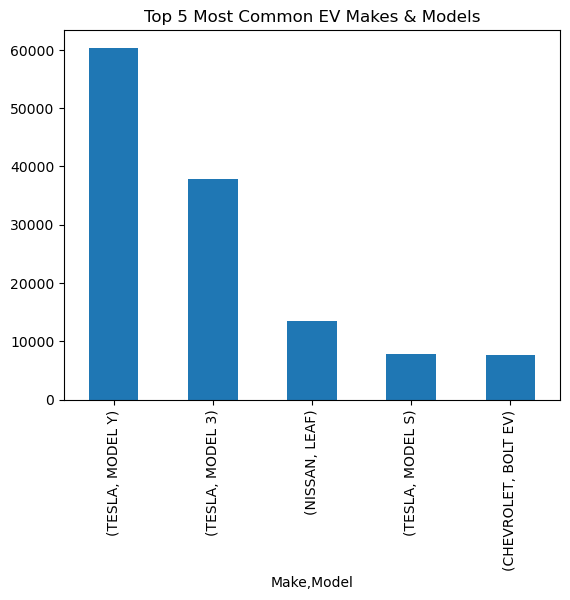

In [45]:
# What are the top 5 most common EV makes and models in the dataset?

top_makes = df.groupby(['Make', 'Model']).size().sort_values(ascending=False).head()
print(top_makes)

top_makes.plot(kind='bar')
plt.title('Top 5 Most Common EV Makes & Models')
plt.show()

County
King         138288
Snohomish     35137
Pierce        23041
Clark         17315
Thurston      10220
Name: count, dtype: int64


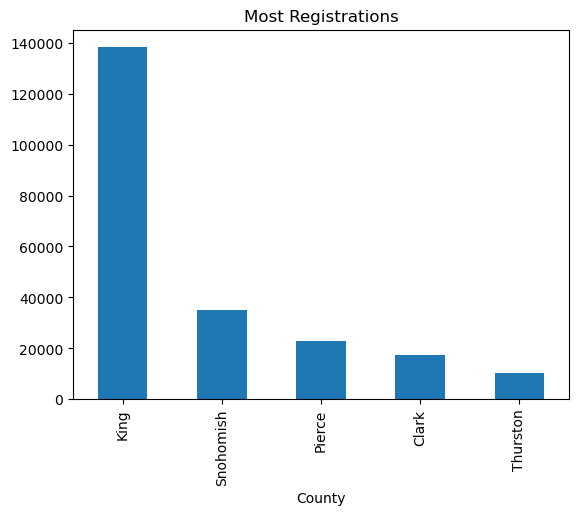

In [46]:
# What is the distribution of EVs by county? Which county has the most registrations?

top_county = df['County'].value_counts().head()
print(top_county)

top_county.plot(kind='bar')
plt.title('Most Registrations')
plt.show()

Model Year
1999        2
2000        7
2002        1
2003        1
2008       19
2010       22
2011      573
2012     1366
2013     3914
2014     3173
2015     4394
2016     5068
2017     8400
2018    13958
2019    10777
2020    12042
2021    20746
2022    29924
2023    60333
2024    49544
2025    36867
2026    19678
2027       24
Name: count, dtype: int64


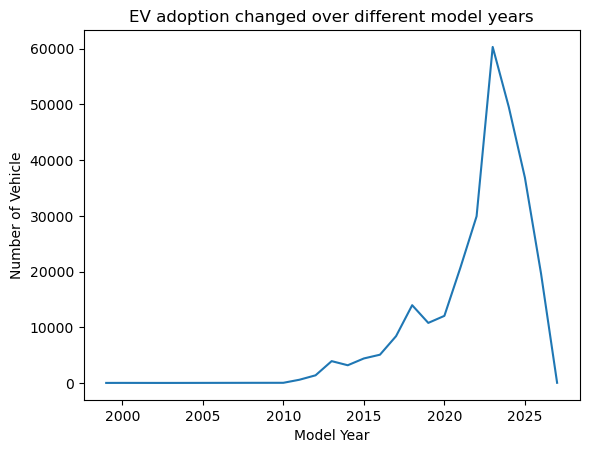

In [47]:
# How has EV adoption changed over different model years?

year_trends = df['Model Year'].value_counts().sort_index()
print(year_trends)

year_trends.plot(kind='line')
plt.title('EV adoption changed over different model years')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicle')
plt.show()

In [48]:
# What is the average electric range of EVs in the dataset?

avg_range = df['Electric Range'].mean()
print(avg_range)

68.8055427958965


In [49]:
# What percentage of EVs are eligible for Clean Alternative Fuel Vehicle (CAFV) incentives?

cafv_percent = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts(normalize=True) * 100
print(cafv_percent )


Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    63.930521
Clean Alternative Fuel Vehicle Eligible                         27.465789
Not eligible due to low battery range                            8.603690
Name: proportion, dtype: float64


Make        Model           
TESLA       ROADSTER            231.212766
JAGUAR      I-PACE              181.098684
CHEVROLET   BOLT EV             180.698351
TESLA       MODEL S             175.187460
AUDI        E-TRON              141.797628
TESLA       MODEL X             135.269791
PORSCHE     MACAN               127.192771
AUDI        E-TRON SPORTBACK    121.178082
TESLA       MODEL 3             113.723200
VOLKSWAGEN  E-GOLF              107.686712
Name: Electric Range, dtype: float64


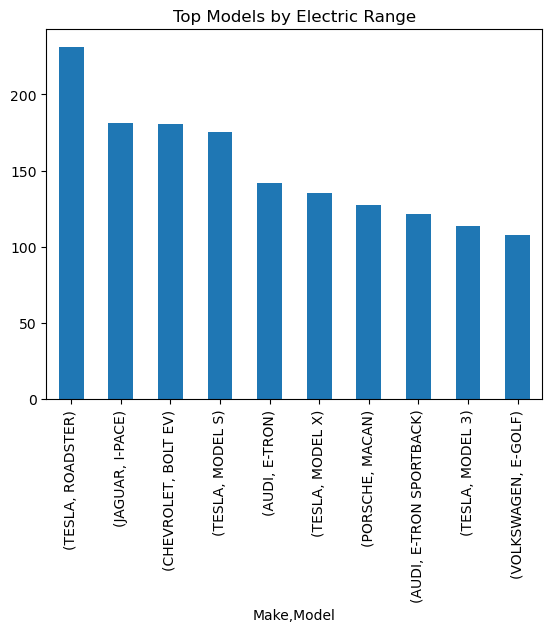

In [50]:
# How does the electric range vary across different makes and models?

range_by_makes_models = df.groupby(['Make', 'Model'])['Electric Range'].mean().sort_values(ascending=False).head(10)
print(range_by_makes_models)

range_by_makes_models.plot(kind = 'bar')
plt.title('Top Models by Electric Range')
plt.show()

{'Urban': np.int64(122219), 'Rural': np.int64(158614)}


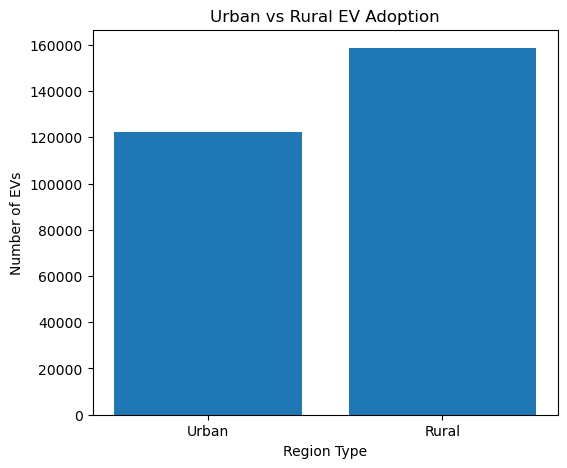

In [64]:
# Are there any regional trends in EV adoption (e.g., urban vs. rural areas)?

city_counts = df['City'].value_counts()

urban_cities = city_counts[city_counts > 5000]
rural_cities = city_counts[city_counts <= 5000]

urban_total = urban_cities.sum()
rural_total = rural_cities.sum()

region_data = {
    'Urban': urban_total,
    'Rural': rural_total
}

print(region_data)

plt.figure(figsize=(6,5))

plt.bar(region_data.keys(), region_data.values())

plt.title('Urban vs Rural EV Adoption')
plt.xlabel('Region Type')
plt.ylabel('Number of EVs')

plt.show()

# Section 3: Data Visualization

Make
TESLA        114817
CHEVROLET     19410
NISSAN        16153
FORD          15423
KIA           14101
Name: count, dtype: int64


Text(0, 0.5, 'Count')

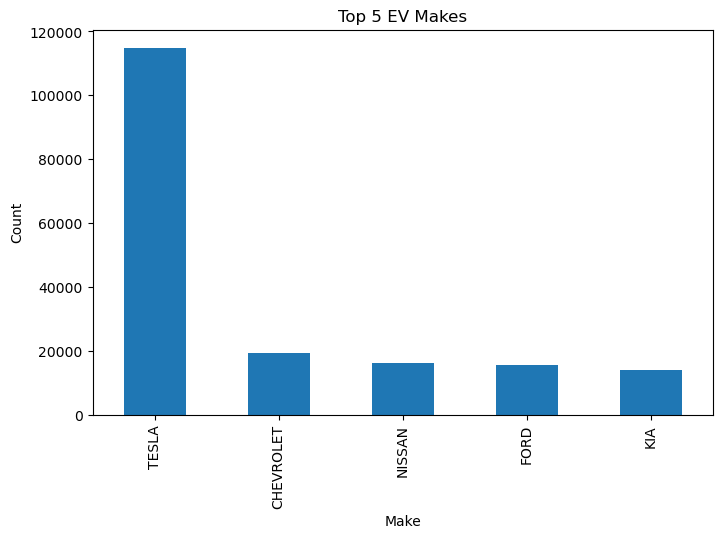

In [68]:
# Create a bar chart showing the top 5 EV makes and models by count.

Top_Makes = df['Make'].value_counts().head(5)
print(Top_Makes)

Top_Makes.plot(kind='bar', figsize=(8,5))
plt.title('Top 5 EV Makes')
plt.xlabel('Make')
plt.ylabel('Count')


       County  EV Count
0        King    138288
1   Snohomish     35137
2      Pierce     23041
3       Clark     17315
4    Thurston     10220
5      Kitsap      9563
6     Spokane      7864
7     Whatcom      6872
8      Benton      4020
9      Skagit      3343
10     Island      3054
11     Yakima      1961
12     Chelan      1784
13    Clallam      1697
14  Jefferson      1519
15    Cowlitz      1493
16      Mason      1437
17   San Juan      1290
18      Lewis      1240
19   Franklin      1216


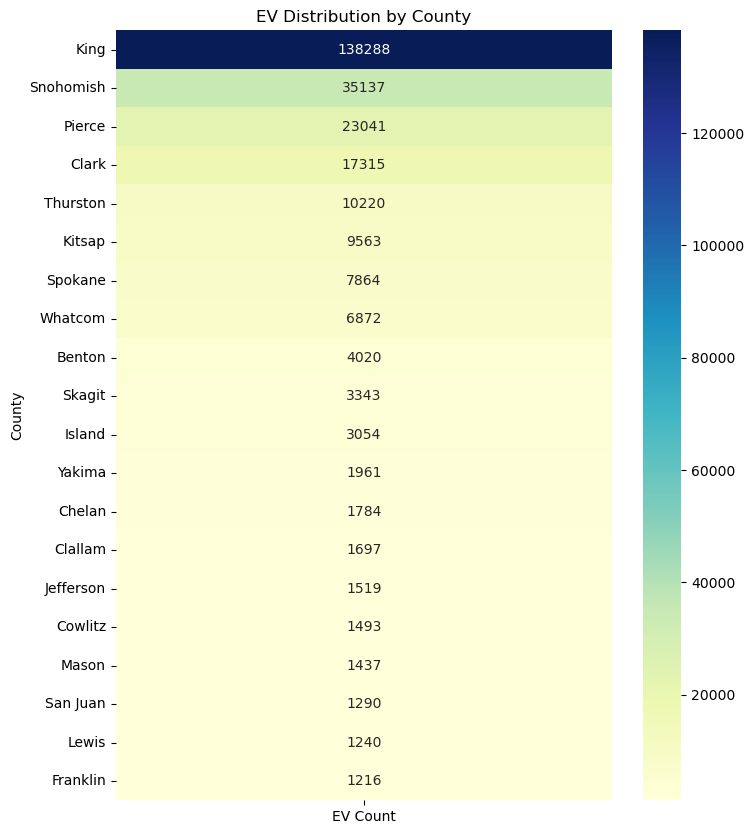

In [76]:
# Use a heatmap or choropleth map to visualize EV distribution by county.

county_counts = df['County'].value_counts().head(20)

county_df = county_counts.reset_index()
county_df.columns = ['County', 'EV Count']
print(county_df)

heatmap_data = county_df.set_index('County')

# Plot Heatmap
plt.figure(figsize=(8,10))

sns.heatmap(heatmap_data,
            annot=True,
            fmt='g',
            cmap='YlGnBu')

plt.title('EV Distribution by County')

plt.show()

Model Year
1999        2
2000        7
2002        1
2003        1
2008       19
2010       22
2011      573
2012     1366
2013     3914
2014     3173
2015     4394
2016     5068
2017     8400
2018    13958
2019    10777
2020    12042
2021    20746
2022    29924
2023    60333
2024    49544
2025    36867
2026    19678
2027       24
Name: count, dtype: int64


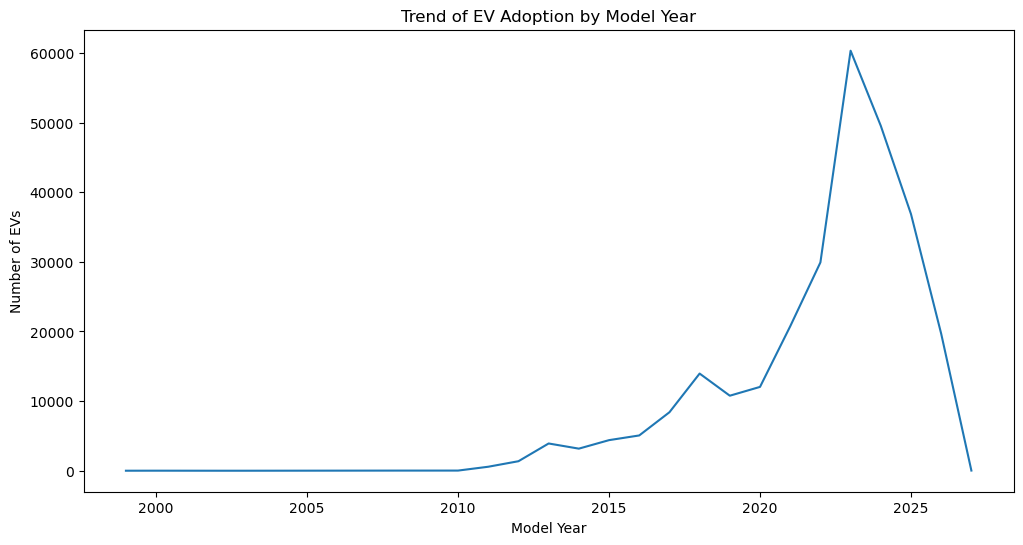

In [81]:
# Create a line graph showing the trend of EV adoption by model year.

year_trend = df['Model Year'].value_counts().sort_index()

print(year_trend)

year_trend.plot(kind='line', figsize=(12,6))
plt.title('Trend of EV Adoption by Model Year')
plt.xlabel('Model Year')
plt.ylabel('Number of EVs')

plt.show()

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Eligibility unknown as battery range has not been researched    179538
Clean Alternative Fuel Vehicle Eligible                          77133
Not eligible due to low battery range                            24162
Name: count, dtype: int64


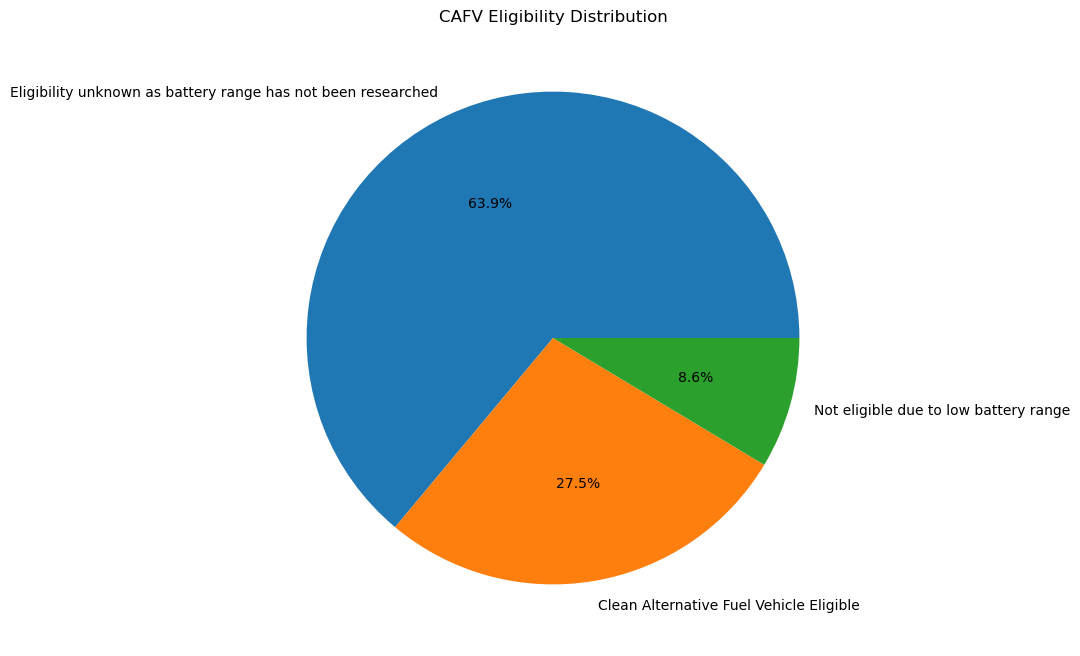

In [87]:
# Plot a pie chart showing the proportion of CAFV-eligible vs. non-eligible EVs.

cafv_counts = df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()

print(cafv_counts)

plt.figure(figsize=(8,8))

plt.pie(cafv_counts,
        labels=cafv_counts.index,
        autopct='%1.1f%%')

plt.title('CAFV Eligibility Distribution')

plt.show()

In [95]:
!pip install folium

Defaulting to user installation because normal site-packages is not writeable


In [96]:
# Use a geospatial map to display EV registrations based on vehicle location.

import folium

ev_map = folium.Map(
    location=[
        map_data['Latitude'].mean(),
        map_data['Longitude'].mean()
    ],
    zoom_start=7
)

# Add EV registration points
for i in range(min(1000, len(map_data))):
    folium.CircleMarker(
        location=[
            map_data.iloc[i]['Latitude'],
            map_data.iloc[i]['Longitude']
        ],
        radius=2,
        fill=True
    ).add_to(ev_map)

ev_map

In [98]:
print(df.columns)
df.head(2)

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Electric Utility',
       '2020 Census Tract', 'Longitude', 'Latitude', 'VIN_Anonymized',
       'Region Type'],
      dtype='object')


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Electric Utility,2020 Census Tract,Longitude,Latitude,VIN_Anonymized,Region Type
0,1N4AZ0CP6D,King,Kirkland,WA,98034.0,2013,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,75.0,1.0,154635729,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10,-122.22901,47.72201,25e6a27ac0ce5328a0ccb723ba3f51c311f2904004ae04...,Rural
1,5YJ3E1EC8L,Kitsap,Bainbridge Island,WA,98110.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,308.0,23.0,107518645,PUGET SOUND ENERGY INC,5.303509e+10,-122.52100,47.62759,9bdcc96fd653d922b7197ec170319ed7e503614272f520...,Rural


# Section 4: Linear Regression Model

In [101]:
# How can we use Linear Regression to predict the Electric Range of a vehicle?

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

data = df[['Model Year', 'Make', 'Electric Vehicle Type', 'Electric Range']]

data = data.dropna()

# Convert categorical columns into numeric
data = pd.get_dummies(data, columns=['Make', 'Electric Vehicle Type'], drop_first=True)

X = data.drop('Electric Range', axis=1)
y = data['Electric Range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.376080349304443
Mean Absolute Error: 36.449668786716934


In [103]:
# How do we handle categorical variables like Make and Model in regression analysis?

data = df[['Model', 'Make']]

data = pd.get_dummies(data, columns=['Make', 'Model'], drop_first=True)

print(data.head())

   Make_ALFA ROMEO  Make_AUDI  Make_AZURE DYNAMICS  Make_BENTLEY  Make_BMW  \
0            False      False                False         False     False   
1            False      False                False         False     False   
2            False      False                False         False     False   
3            False      False                False         False     False   
4            False      False                False         False     False   

   Make_BRIGHTDROP  Make_CADILLAC  Make_CHEVROLET  Make_CHRYSLER  Make_DODGE  \
0            False          False           False          False       False   
1            False          False           False          False       False   
2            False          False           False          False       False   
3            False          False           False          False       False   
4            False          False           False          False       False   

   ...  Model_WHEEGO  Model_WRANGLER  Model_X3  Mo

In [106]:
# What is the R² score of the model, and what does it indicate about prediction accuracy?

if r2_score(y_test, y_pred) >= 0.8:
    print("The model has very good prediction accuracy.")
elif r2_score(y_test, y_pred) >= 0.5:
    print("The model has moderate prediction accuracy.")
else:
    print("The model has low prediction accuracy.")

The model has low prediction accuracy.


# Conclusion

This project provided valuable insights into electric vehicle adoption trends, regional distribution, and vehicle characteristics.

Key findings from the analysis include:
- Significant growth in EV adoption over recent years
- Tesla being the dominant EV manufacturer
- Higher EV adoption in urban regions compared to rural areas
- Strong relationship between vehicle specifications and electric range

The Linear Regression model demonstrated how machine learning can be used to predict EV electric range based on vehicle attributes. Overall, the project highlighted the growing importance of electric vehicles and data-driven analysis in the automotive industry.